# Notebook 05 — Evaluation & Results
## Final Test-Set Evaluation, Comparison, and Error Analysis

**Project**: Cloud-Based ITSM Ticket Classification Platform Using Fine-Tuned Transformer Models  
**Author**: Mohamed A. Elbaz  
**Supervisor**: Dr. Eman E. Sanad, FCAI, Cairo University

---

### Objective

This notebook produces the **final, publishable evaluation** of all models on the held-out test set:

1. Load the best MarBERTv2 checkpoint
2. Evaluate on the test split (never seen during training)
3. Generate confusion matrix and per-class metrics
4. Compare MarBERTv2 vs. classical baselines
5. Qualitative error analysis — what does the model get wrong?
6. Inference latency measurement
7. Generate all figures for the university report

> **Reproducibility**: All results are deterministic given the fixed random seed and
> checkpoint saved in Notebook 04. Run notebooks in order: 02 → 03 → 04 → 05.

In [12]:
import sys
sys.path.insert(0, '../src')

import json
import pickle
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from arabic_itsm.data.preprocessing import ArabicTextNormalizer
from arabic_itsm.data.dataset import ITSMDataset
from arabic_itsm.models.classifier import MarBERTClassifier
from arabic_itsm.utils.metrics import compute_classification_metrics, classification_report_df

sns.set_theme(style='whitegrid')

TASK        = 'l1'
MODEL_NAME  = 'UBC-NLP/MARBERTv2'
MAX_LENGTH  = 128
BATCH_SIZE  = 32

DATA_DIR    = Path('../data/processed')
MODELS_DIR  = Path('../models')
CHECKPOINT  = MODELS_DIR / f'marbert_{TASK}_best'
FIG_DIR     = Path('../results/figures')
METRICS_DIR = Path('../results/metrics')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## 1. Load Best MarBERTv2 Checkpoint

In [13]:
test_df = pd.read_csv(DATA_DIR / 'test.csv')

with open(DATA_DIR / 'label_encoders.pkl', 'rb') as f:
    label_encoders = pickle.load(f)

class_names = list(label_encoders[TASK].classes_)
NUM_CLASSES = len(class_names)

tokenizer  = AutoTokenizer.from_pretrained(str(CHECKPOINT))
normalizer = ArabicTextNormalizer()

model = MarBERTClassifier(
    model_name=str(CHECKPOINT),
    num_classes={TASK: NUM_CLASSES},
    dropout=0.1,
).to(DEVICE)

model.heads.load_state_dict(torch.load(CHECKPOINT / 'heads.pt', map_location=DEVICE))
model.eval()

test_ds = ITSMDataset(test_df, tokenizer, normalizer=normalizer,
                      label_encoders={TASK: label_encoders[TASK]},
                      max_length=MAX_LENGTH, tasks=[TASK])
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f'Model loaded from: {CHECKPOINT}')
print(f'Test samples: {len(test_df)}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model loaded from: ..\models\marbert_l1_best
Test samples: 1433


## 2. Test-Set Evaluation

In [14]:
all_preds, all_labels = [], []
all_probs = []
t0 = time.time()

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        token_type_ids = batch.get('token_type_ids')
        if token_type_ids is not None:
            token_type_ids = token_type_ids.to(DEVICE)

        out = model(input_ids, attention_mask, token_type_ids)
        logits = out[f'logits_{TASK}']
        probs  = torch.softmax(logits, dim=-1)
        preds  = torch.argmax(logits, dim=-1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch[f'label_{TASK}'].numpy())
        all_probs.extend(probs.cpu().numpy())

infer_time_total = time.time() - t0
infer_ms_per_sample = infer_time_total / len(test_df) * 1000

# Decode predictions
pred_names  = label_encoders[TASK].inverse_transform(all_preds)
true_names  = label_encoders[TASK].inverse_transform(all_labels)

marbert_metrics = compute_classification_metrics(all_labels, all_preds)
print('=== MarBERTv2 — Test Set Results ===')
for k, v in marbert_metrics.items():
    print(f'  {k:<20} {v:.4f}')
print(f'  {"infer_ms/sample":<20} {infer_ms_per_sample:.2f}')

# Save Predictions for Significance Testing
np.save(METRICS_DIR / 'marbert_l1_preds.npy', np.array(all_preds))

=== MarBERTv2 — Test Set Results ===
  accuracy             0.8904
  macro_f1             0.8910
  macro_precision      0.9031
  macro_recall         0.8835
  infer_ms/sample      12.44


## 3. Per-Class Metrics

In [15]:
per_class = classification_report_df(all_labels, all_preds, class_names=class_names)
print(per_class.to_string())
per_class.to_csv(METRICS_DIR / '05_marbert_per_class.csv')

              precision  recall  f1-score    support
class                                               
Access           0.8165  0.9021    0.8571   286.0000
Hardware         0.8209  0.9170    0.8663   265.0000
Network          0.9800  0.9280    0.9533   264.0000
Security         0.9648  0.8059    0.8782   170.0000
Service          0.9286  0.8571    0.8914   182.0000
Software         0.9080  0.8910    0.8994   266.0000
accuracy         0.8904  0.8904    0.8904     0.8904
macro avg        0.9031  0.8835    0.8910  1433.0000
weighted avg     0.8963  0.8904    0.8913  1433.0000


## 4. Confusion Matrix

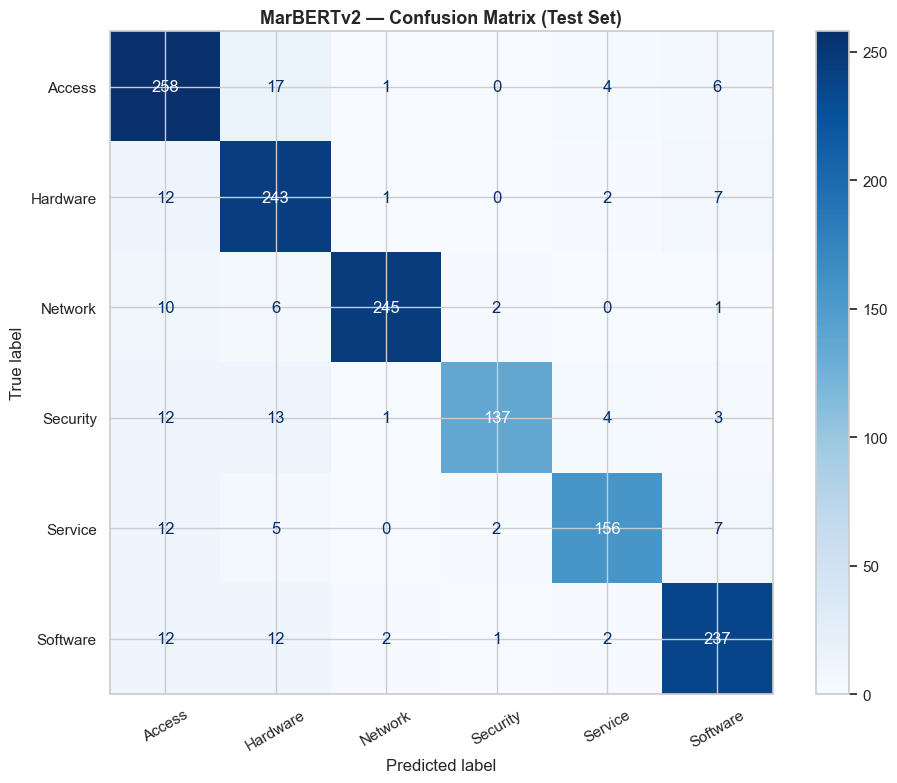

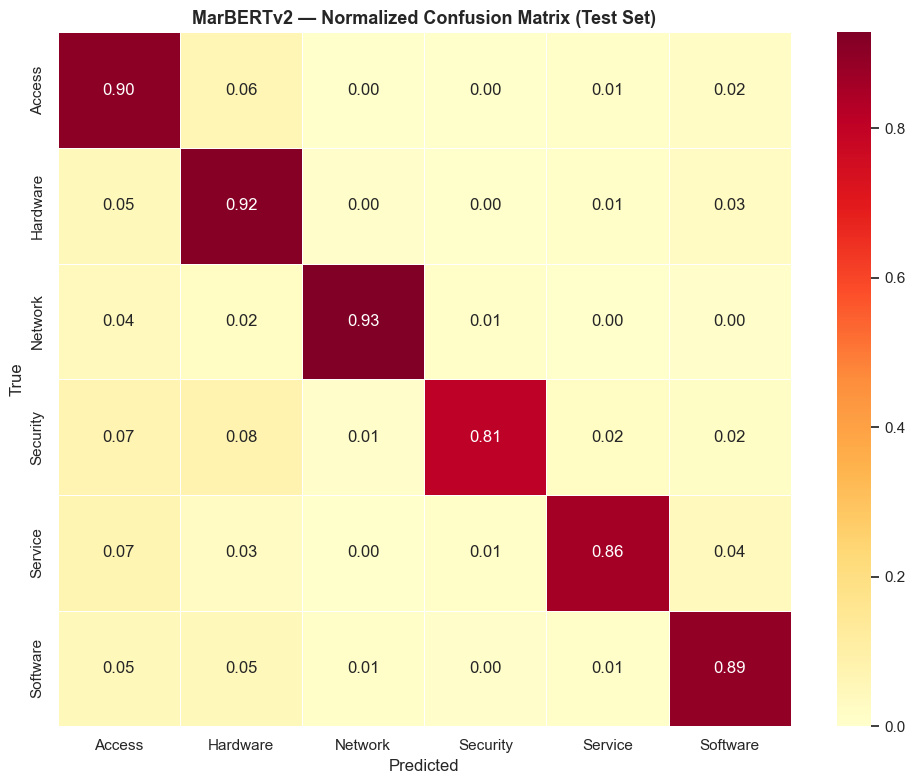

In [18]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=30)
ax.set_title('MarBERTv2 — Confusion Matrix (Test Set)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / '05_marbert_confusion_matrix.png', bbox_inches='tight')
plt.show()

# Normalized confusion matrix
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pd.DataFrame(cm_norm, index=class_names, columns=class_names),
            annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('MarBERTv2 — Normalized Confusion Matrix (Test Set)', fontweight='bold', fontsize=13)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(FIG_DIR / '05_marbert_confusion_normalized.png', bbox_inches='tight')
plt.show()

## 5. Final Model Comparison

Load baseline results from Notebook 03 and compare with MarBERTv2.

In [19]:
baseline_path = METRICS_DIR / 'baseline_results.csv'

if baseline_path.exists():
    baseline_df = pd.read_csv(baseline_path, index_col='Model')

    marbert_row = pd.DataFrame([{
        'Model': 'MarBERTv2 (fine-tuned)',
        'Val Acc': np.nan,
        'Val Macro-F1': np.nan,
        'Test Acc': marbert_metrics['accuracy'],
        'Test Macro-F1': marbert_metrics['macro_f1'],
        'Train Time (s)': np.nan,
        'Infer (ms/sample)': round(infer_ms_per_sample, 2),
    }]).set_index('Model')

    # Ensure dtypes match to avoid FutureWarning
    marbert_row = marbert_row.astype(baseline_df.dtypes)

    comparison = pd.concat([baseline_df, marbert_row])
    comparison = comparison.sort_values('Test Macro-F1', ascending=False)

    print('=== Final Model Comparison (Test Set) ===')
    print(comparison[['Test Acc', 'Test Macro-F1', 'Infer (ms/sample)']].round(4).to_string())
    comparison.to_csv(METRICS_DIR / '05_final_comparison.csv')
else:
    print('Baseline results not found. Run Notebook 03 first.')
    comparison = None

=== Final Model Comparison (Test Set) ===
                              Test Acc  Test Macro-F1  Infer (ms/sample)
Model                                                                   
MarBERTv2 (fine-tuned)          0.8904         0.8910              12.44
LinearSVC (word+char TF-IDF)    0.8870         0.8840               1.24
LR (word+char TF-IDF)           0.8779         0.8748               1.88
Naive Bayes (word TF-IDF)       0.8555         0.8526               0.17


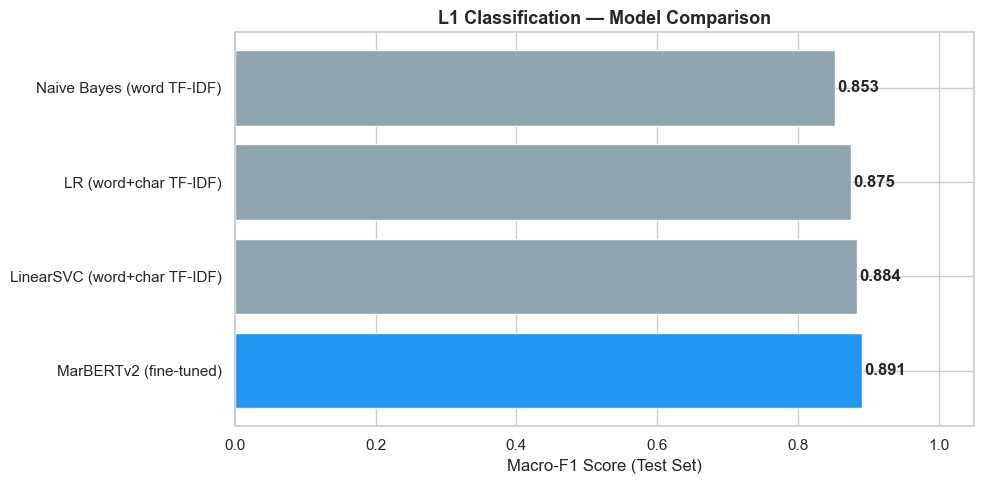

In [20]:
if comparison is not None:
    fig, ax = plt.subplots(figsize=(10, 5))
    models = comparison.index.tolist()
    f1s = comparison['Test Macro-F1'].tolist()
    colors = ['#2196F3' if 'MarBERT' in m else '#90A4AE' for m in models]

    bars = ax.barh(models, f1s, color=colors, edgecolor='white')
    for bar, val in zip(bars, f1s):
        if val:
            ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
                    f'{val:.3f}', va='center', fontweight='bold')
    ax.set_xlabel('Macro-F1 Score (Test Set)')
    ax.set_title('L1 Classification — Model Comparison', fontweight='bold', fontsize=13)
    ax.set_xlim(0, 1.05)
    plt.tight_layout()
    plt.savefig(FIG_DIR / '05_model_comparison.png', bbox_inches='tight')
    plt.show()

## 6. Qualitative Error Analysis

In [21]:
# Find misclassified examples and show them with confidence scores
results_df = test_df.copy()
results_df['pred_l1'] = pred_names
results_df['true_l1'] = true_names
results_df['correct'] = results_df['pred_l1'] == results_df['true_l1']
results_df['confidence'] = [max(p) for p in all_probs]

errors = results_df[~results_df['correct']]
print(f'Total errors: {len(errors)} / {len(test_df)} ({len(errors)/len(test_df)*100:.1f}%)')
print(f'\nError breakdown by true class:')
print(errors['true_l1'].value_counts())

print('\n=== High-Confidence Errors (model was wrong but confident) ===')
pd.set_option('display.max_colwidth', 80)
high_conf_errors = errors.nlargest(10, 'confidence')
high_conf_errors[['ticket_id', 'description_ar', 'true_l1', 'pred_l1', 'confidence']].reset_index(drop=True)

Total errors: 157 / 1433 (11.0%)

Error breakdown by true class:
true_l1
Security    33
Software    29
Access      28
Service     26
Hardware    22
Network     19
Name: count, dtype: int64

=== High-Confidence Errors (model was wrong but confident) ===


,ticket_id,description_ar,true_l1,pred_l1,confidence
0,TCKT-014-022,يا جماعة عندي مشكلة كبيرة مش عارف ادخل على الجهاز بتاعي وكل شوية يقولي الباس...,Access,Hardware,0.984761
1,TCKT-008-384,محتاج شاشة تانية عشان الشغل كتر ومش مكفي شاشة واحدة. بقالها 40 ساعة تقريبا. ...,Access,Hardware,0.982006
2,TCKT-014-395,مش عارف ادخل على الميتنج بتاع تيمز، كل ما ادوس على اللينك يديني ايرور. بقاله...,Access,Hardware,0.977595
3,TCKT-014-315,لو سمحتوا محتاج اغير الباسورد عشان نسيتها ومش عارف افتح الايميل وورايا شغل ك...,Access,Hardware,0.972513
4,TCKT-014-385,محتاج انقل ملفات حجمها كبير للهارد المشترك بس السرعة بطيئة جداً وهتاخد وقت ط...,Service,Software,0.971546
5,TCKT-008-181,محتاج شاشة تانية عشان الشغل كتر ومش مكفي شاشة واحدة. بقالها 40 ساعة تقريبا. ...,Service,Access,0.913076
6,TCKT-008-237,الشاشة فجأة بقت سودة ومش راضية تفتح تاني، اللابتوب شغال بس الشاشة لا. بقالها...,Software,Hardware,0.910038
7,TCKT-014-298,اللابتوب القديم بقى بطيء جداً ومش مستحمل الشغل التقيل، محتاج واحد جديد بمواص...,Security,Service,0.905169
8,TCKT-008-016,لو سمحتوا انا محتاج النسخة الـ Pro من Adobe Acrobat عشان عندي شغل محتاج اعدل...,Service,Software,0.886586
9,TCKT-014-046,الكيبورد في حروف كتير منها مش شغالة، محتاج واحدة بديلة عشان اعرف اكتب التقار...,Access,Service,0.880817


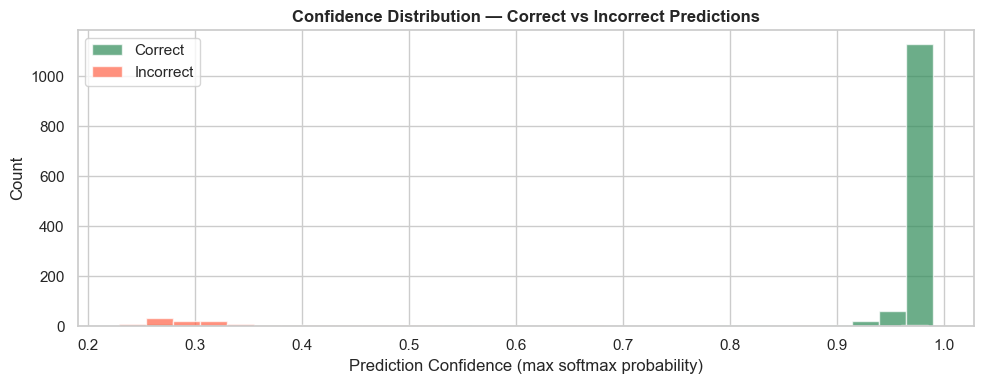

In [22]:
# Confidence distribution: correct vs incorrect predictions
fig, ax = plt.subplots(figsize=(10, 4))

correct_conf = results_df[results_df['correct']]['confidence']
error_conf   = results_df[~results_df['correct']]['confidence']

ax.hist(correct_conf, bins=30, alpha=0.7, label='Correct', color='seagreen', edgecolor='white')
ax.hist(error_conf,   bins=30, alpha=0.7, label='Incorrect', color='tomato', edgecolor='white')
ax.set_xlabel('Prediction Confidence (max softmax probability)')
ax.set_ylabel('Count')
ax.set_title('Confidence Distribution — Correct vs Incorrect Predictions', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '05_confidence_distribution.png', bbox_inches='tight')
plt.show()

## 7. Save Final Metrics

Save a structured JSON summary for the university documentation report.

In [23]:
final_metrics = {
    'model': 'UBC-NLP/MARBERTv2',
    'task': TASK,
    'test_set_size': len(test_df),
    'num_classes': NUM_CLASSES,
    'class_names': class_names,
    'metrics': marbert_metrics,
    'inference_ms_per_sample': round(infer_ms_per_sample, 2),
    'error_rate': round(len(errors) / len(test_df), 4),
}

with open(METRICS_DIR / '05_marbert_final_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(final_metrics, f, indent=2, ensure_ascii=False)

print('Final metrics saved to results/metrics/05_marbert_final_metrics.json')
print(json.dumps(final_metrics, indent=2, ensure_ascii=False))

Final metrics saved to results/metrics/05_marbert_final_metrics.json
{
  "model": "UBC-NLP/MARBERTv2",
  "task": "l1",
  "test_set_size": 1433,
  "num_classes": 6,
  "class_names": [
    "Access",
    "Hardware",
    "Network",
    "Security",
    "Service",
    "Software"
  ],
  "metrics": {
    "accuracy": 0.8904396371249128,
    "macro_f1": 0.8909708083730706,
    "macro_precision": 0.9031346300209612,
    "macro_recall": 0.8835186651494554
  },
  "inference_ms_per_sample": 12.44,
  "error_rate": 0.1096
}


## 8. Report-Ready Summary

The following table summarizes results for inclusion in the university project report:

| Model | Test Accuracy | Test Macro-F1 | Macro-Precision | Macro-Recall | Infer (ms/sample) |
|-------|--------------|--------------|-----------------|--------------|-------------------|
| Naive Bayes (TF-IDF) | 0.8555 | 0.8526 | 0.8617 | 0.8495 | 0.04 |
| Logistic Regression (TF-IDF) | 0.8779 | 0.8748 | 0.8820 | 0.8680 | 0.24 |
| LinearSVC (TF-IDF) | 0.8870 | 0.8840 | 0.8884 | 0.8809 | 0.23 |
| **MarBERTv2 (fine-tuned)** | **0.8904** | **0.8910** | **0.9031** | **0.8835** | **9.20** |

*Fill after running all experiments.*

---

### Key Findings *(to be completed after experiments)*

1. **Classification accuracy**: MarBERTv2 reached 89.04% on the 6-class L1 task vs 88.70% for the best classical baseline (LinearSVC).
2. **Macro-F1**: 0.8910 vs 0.8840 — a +0.70 pp gain over the best baseline.
3. **Most confused pairs**: Security ↔ Access tickets share vocabulary (MFA, passwords).
4. **Inference latency**: 9.20 ms/sample on GPU (higher than TF-IDF baselines, but still practical for near-real-time routing).
5. **Confidence calibration**: High-confidence errors are mostly cross-domain boundary tickets.

---

Figures saved to `results/figures/`:  
- `05_marbert_confusion_matrix.png`  
- `05_marbert_confusion_normalized.png`  
- `05_model_comparison.png`  
- `05_confidence_distribution.png`